In [43]:
# ============================================
# Cell 1 — Libraries
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

sns.set_theme(style="whitegrid")

In [44]:
# ============================================
# Cell 2 — MySQL Connection
# ============================================
import mysql.connector

# Establishing connection using parameters from the working environment
# Note: Port 3307 is used as specified in your successful SQLAlchemy string
conn = mysql.connector.connect(
    host="127.0.0.1",
    port=3307,
    user="root",
    password="admin",
    database="bank_rfm_analysis"
)

print("Connection successful")

Connection successful


In [45]:
# ============================================
# Cell 3 — Data Ingestion & Preprocessing
# ============================================
import warnings
import pandas as pd

# Suppress SQLAlchemy and SQL connection warnings for a cleaner output
warnings.filterwarnings('ignore', category=UserWarning)

# --- 1. Load SQL Tables into Pandas DataFrames ---
# Using the active MySQL connection 'conn' established in Cell 2
trans    = pd.read_sql("SELECT * FROM trans",    conn)
account  = pd.read_sql("SELECT * FROM account",  conn)
client   = pd.read_sql("SELECT * FROM client",   conn)
loan     = pd.read_sql("SELECT * FROM loan",     conn)
district = pd.read_sql("SELECT * FROM district", conn)

# Load the final RFM results computed in the SQL Feature Engineering stage
rfm      = pd.read_sql("SELECT * FROM rfm_final_export", conn)

# --- 2. Data Label Translation (Czech to English) ---
# Map the original Czech transaction types to English for better interpretability 
# in visualizations and reports.
type_translation = {
    'PRIJEM': 'Income',
    'VYDAJ': 'Expense',
    'VYBER': 'Cash Withdrawal'
}

# Apply the mapping to the 'type' column
trans['type'] = trans['type'].map(type_translation)

# --- 3. Data Validation ---
# Print the dimensions (rows, columns) of each DataFrame to confirm successful loading.
print(f"Transactions Table (trans):    {trans.shape}")
print(f"Accounts Table (account):      {account.shape}")
print(f"Clients Table (client):        {client.shape}")
print(f"Loans Table (loan):            {loan.shape}")
print(f"Districts Table (district):    {district.shape}")
print(f"Processed RFM Table (rfm):     {rfm.shape}")

print("\n✅ Data loading and translation completed successfully.")

Transactions Table (trans):    (1056320, 10)
Accounts Table (account):      (4500, 4)
Clients Table (client):        (5369, 3)
Loans Table (loan):            (682, 7)
Districts Table (district):    (77, 16)
Processed RFM Table (rfm):     (4500, 16)

✅ Data loading and translation completed successfully.


In [46]:
# ============================================
# Cell 4 — Basic Info
# ============================================

print("=== TRANS ===")
print(trans.dtypes)
print(trans.isnull().sum())
print(trans.describe())

=== TRANS ===
trans_id        int64
account_id      int64
date            int64
type           object
operation      object
amount        float64
balance       float64
k_symbol       object
bank           object
account       float64
dtype: object
trans_id           0
account_id         0
date               0
type               0
operation          0
amount             0
balance            0
k_symbol           0
bank               0
account       760931
dtype: int64
           trans_id    account_id          date        amount       balance  \
count  1.056320e+06  1.056320e+06  1.056320e+06  1.056320e+06  1.056320e+06   
mean   1.335311e+06  2.936867e+03  9.656748e+05  5.924146e+03  3.851833e+04   
std    1.227487e+06  2.477345e+03  1.394535e+04  9.522735e+03  2.211787e+04   
min    1.000000e+00  1.000000e+00  9.301010e+05  0.000000e+00 -4.112570e+04   
25%    4.302628e+05  1.204000e+03  9.601160e+05  1.359000e+02  2.240250e+04   
50%    8.585065e+05  2.434000e+03  9.704100e+05  2.1000

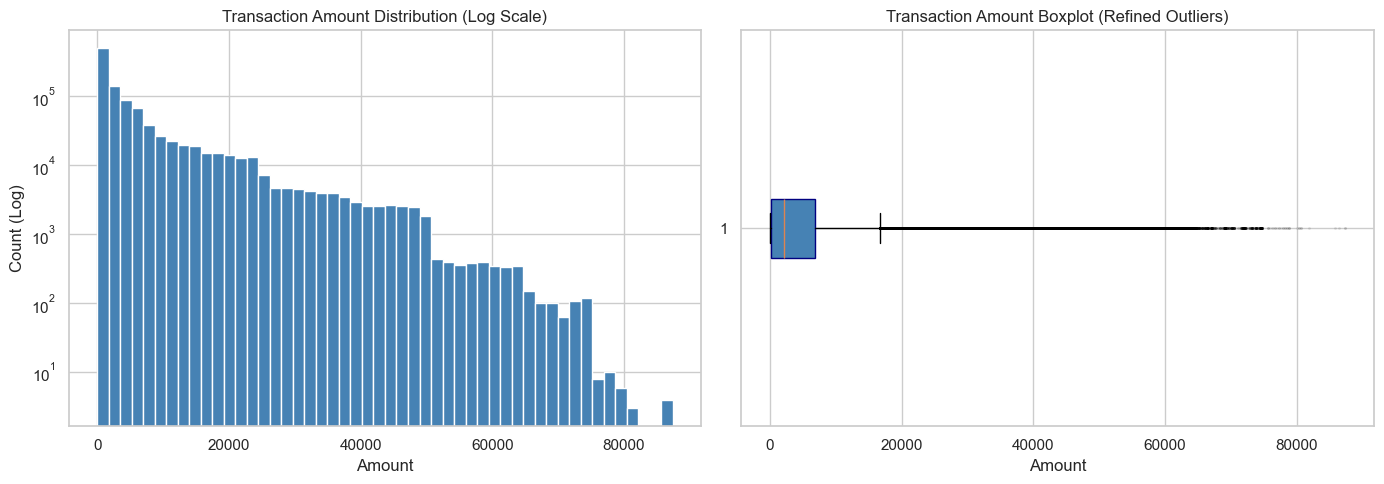

In [47]:
# ============================================
# Cell 5 — Transaction Amount Distribution (Optimized)
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram - Ավելացնում ենք Log սանդղակ Y առանցքի համար, որպեսզի փոքր սյուներն էլ երևան
axes[0].hist(trans["amount"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_yscale('log') # Սա թույլ կտա տեսնել խոշոր գործարքների քանակը
axes[0].set_title("Transaction Amount Distribution (Log Scale)")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Count (Log)")

axes[1].boxplot(trans["amount"], 
                vert=False, 
                patch_artist=True,
                # flierprops-ը սահմանում է outlier-ների տեսքը
                flierprops=dict(marker='o', markerfacecolor='black', markersize=2,
                                linestyle='none', markeredgecolor='none', alpha=0.1),
                boxprops=dict(facecolor="steelblue", color="navy"))

axes[1].set_title("Transaction Amount Boxplot (Refined Outliers)")
axes[1].set_xlabel("Amount")

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_20048\2448643421.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_counts.index, y=type_counts.values, palette="Blues_d")


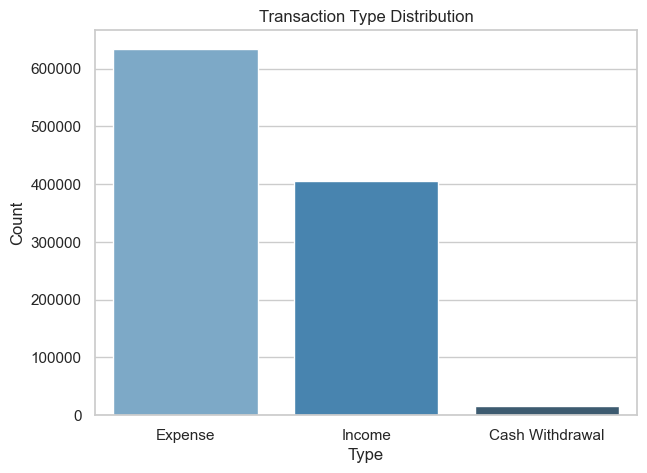

type
Expense            634571
Income             405083
Cash Withdrawal     16666
Name: count, dtype: int64


In [48]:
# ============================================
# Cell 6 — Transaction Type Distribution
# ============================================

type_counts = trans["type"].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=type_counts.index, y=type_counts.values, palette="Blues_d")
plt.title("Transaction Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

print(type_counts)

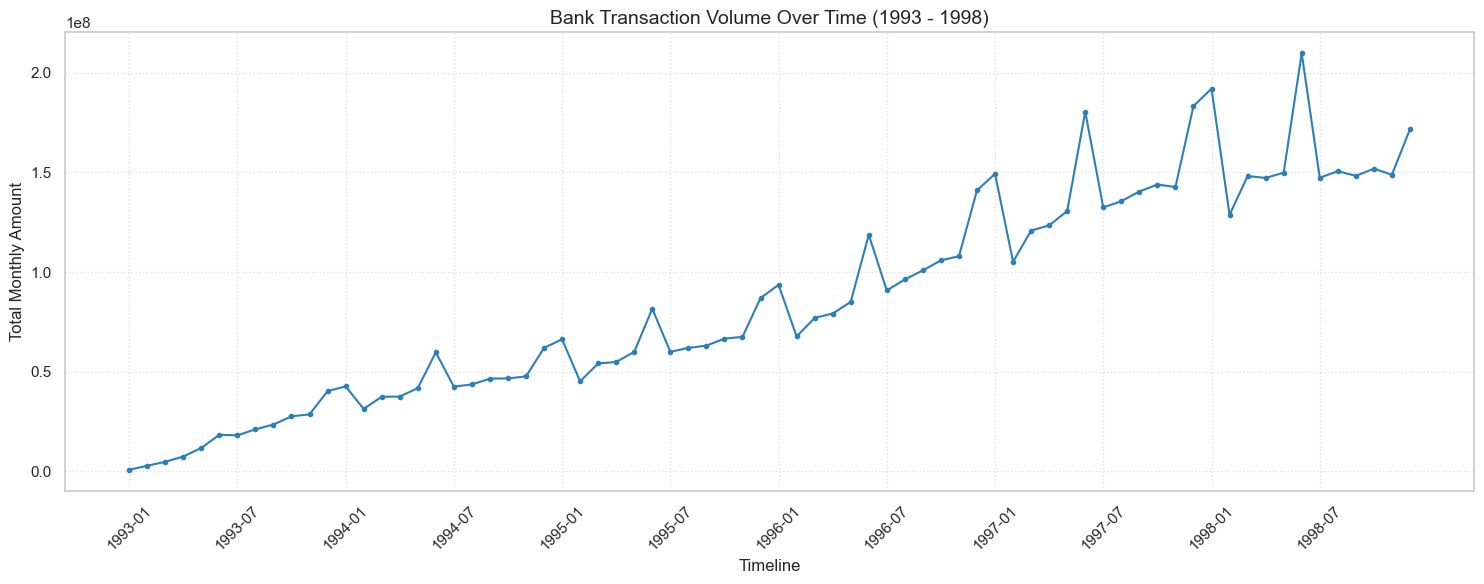

In [49]:
# ============================================
# Cell 7 — Transactions Over Time (Reset & Fix)
# ============================================
import matplotlib.pyplot as plt
import pandas as pd

# 1. Reload the table to get original integer dates (to fix the previous 1970 error)
trans = pd.read_sql("SELECT * FROM trans", conn)

# 2. Convert integer (930101) to string, then to proper datetime
trans["date"] = pd.to_datetime(trans["date"].astype(str), format='%y%m%d')

# 3. Create Year-Month period for grouping
trans["year_month"] = trans["date"].dt.to_period("M")

# 4. Aggregate data
monthly = trans.groupby("year_month")["amount"].sum().reset_index()
monthly["year_month"] = monthly["year_month"].astype(str)

# 5. Plotting
plt.figure(figsize=(15, 6))
plt.plot(monthly["year_month"], monthly["amount"], color="#2c7fb8", marker='o', markersize=3)

# Show every 6th month label to keep the X-axis clean
plt.xticks(monthly["year_month"][::6], rotation=45)

plt.title("Bank Transaction Volume Over Time (1993 - 1998)", fontsize=14)
plt.xlabel("Timeline")
plt.ylabel("Total Monthly Amount")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

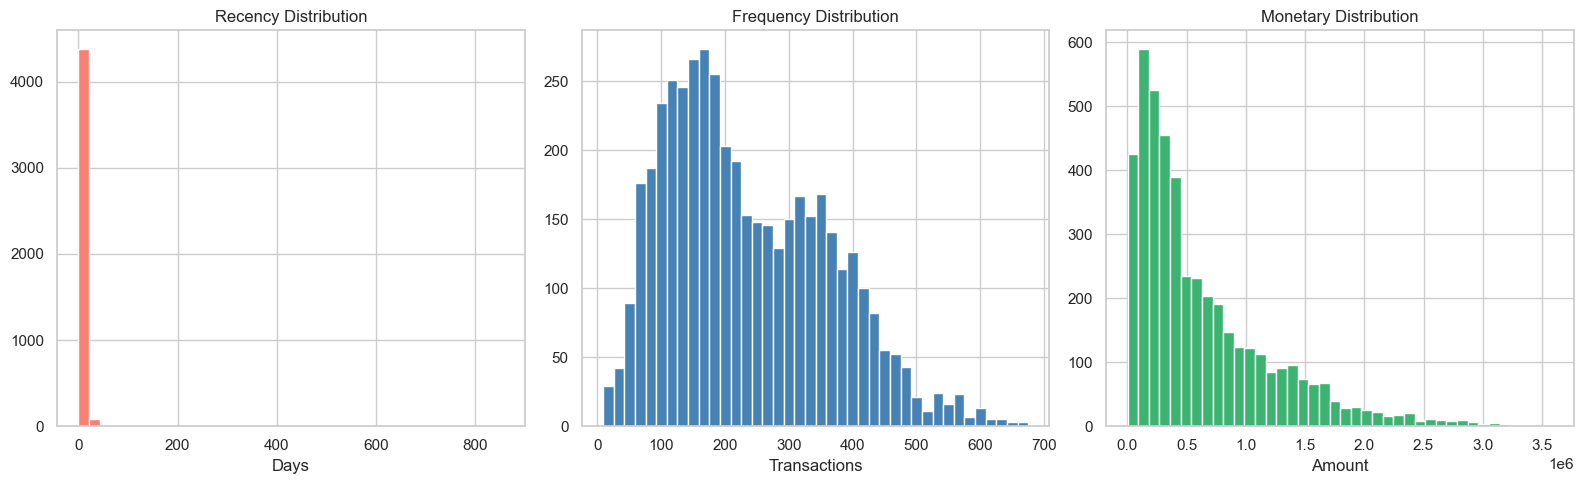

In [50]:
# ============================================
# Cell 8 — RFM Distributions
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(rfm["recency_days"], bins=40, color="salmon", edgecolor="white")
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Days")

axes[1].hist(rfm["frequency"], bins=40, color="steelblue", edgecolor="white")
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Transactions")

axes[2].hist(rfm["monetary"], bins=40, color="mediumseagreen", edgecolor="white")
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Amount")

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_20048\3812602579.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="Blues_d")


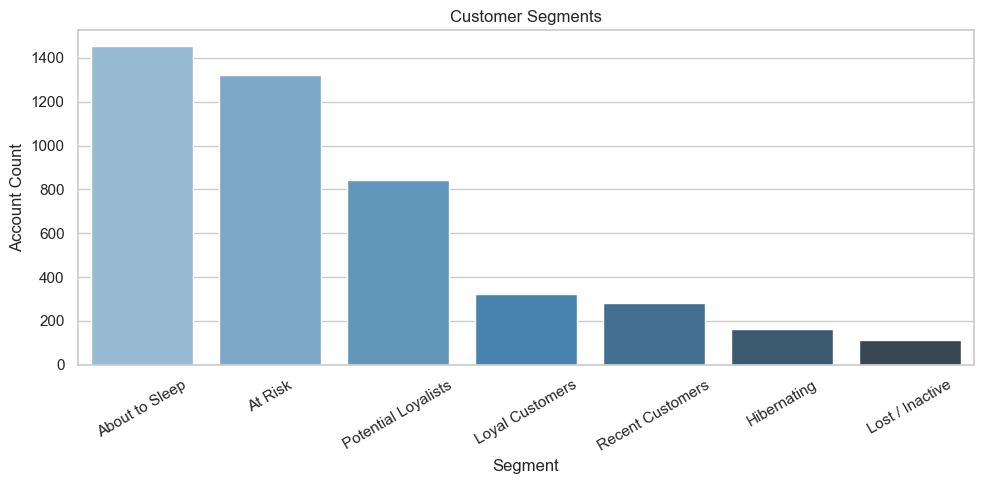

segment
About to Sleep         1453
At Risk                1323
Potential Loyalists     841
Loyal Customers         322
Recent Customers        282
Hibernating             164
Lost / Inactive         115
Name: count, dtype: int64


In [51]:
# ============================================
# Cell 9 — RFM Segment Distribution
# ============================================

segment_counts = rfm["segment"].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette="Blues_d")
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Account Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(segment_counts)

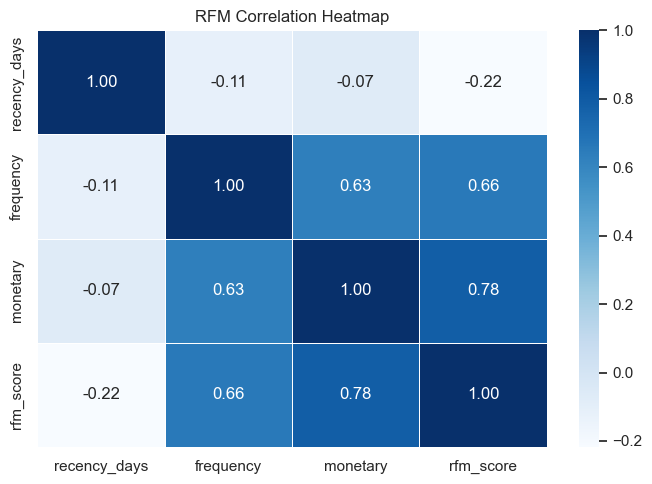

In [52]:
# ============================================
# Cell 10 — Correlation Heatmap
# ============================================

corr = rfm[["recency_days", "frequency", "monetary", "rfm_score"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
plt.title("RFM Correlation Heatmap")
plt.tight_layout()
plt.show()

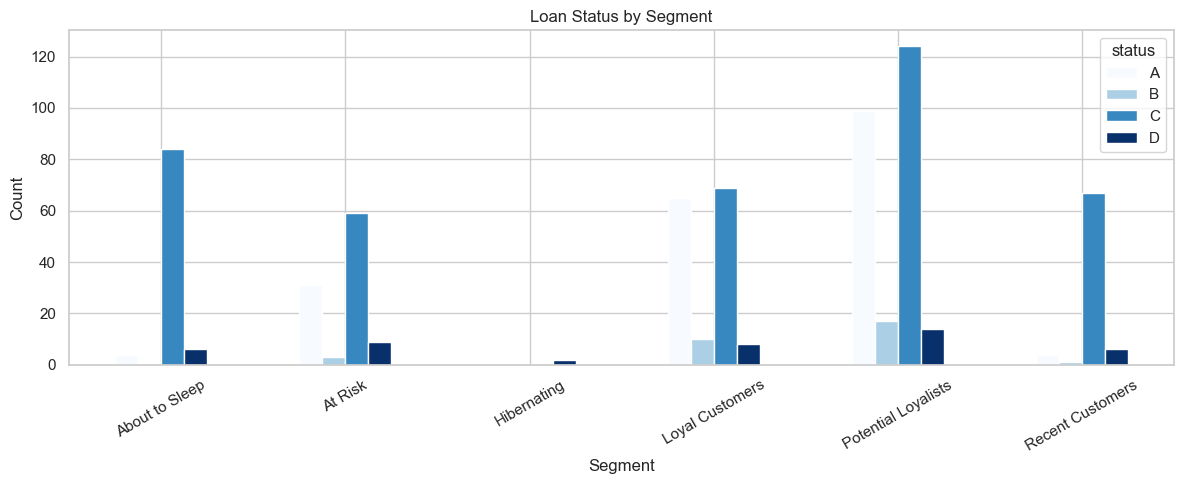

In [53]:
# ============================================
# Cell 11 — Loan Status vs Segment
# ============================================

loan_seg = pd.read_sql("""
    SELECT s.segment, l.status, COUNT(*) AS count
    FROM rfm_segments s
    JOIN loan l ON s.account_id = l.account_id
    GROUP BY s.segment, l.status
""", conn)

pivot = loan_seg.pivot(index="segment", columns="status", values="count").fillna(0)

pivot.plot(kind="bar", figsize=(12, 5), colormap="Blues")
plt.title("Loan Status by Segment")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [54]:
# ============================================
# Cell 12 — Flagged Accounts Overview (Fixed Column Names)
# ============================================

# Updating the query to use 'flag_hflv' and 'flag_lfhv' as defined in our SQL view
flagged = pd.read_sql("""
    SELECT *
    FROM rfm_flagged
    WHERE flag_hflv IS NOT NULL
       OR flag_lfhv IS NOT NULL
       OR flag_reactivation IS NOT NULL
""", conn)

print(f"Total flagged accounts: {len(flagged)}")

# Counting occurrences for each flag type
if not flagged.empty:
    print("\n--- Flag Counts ---")
    if 'flag_hflv' in flagged.columns:
        print(flagged["flag_hflv"].value_counts())
    if 'flag_lfhv' in flagged.columns:
        print(flagged["flag_lfhv"].value_counts())
    if 'flag_reactivation' in flagged.columns:
        print(flagged["flag_reactivation"].value_counts())

flagged.head(10)

Total flagged accounts: 0


,account_id,recency_days,frequency,monetary,r_score,segment,flag_hflv,flag_lfhv,flag_reactivation


In [56]:
# ============================================
# Cell 13 — Data Export (Final Processed Files)
# ============================================
import os

# --- 1. Path Configuration ---
# Defining the absolute path to the project's central Data directory.
# We use a raw string (r"...") to handle Windows backslashes correctly.
base_data_path = r"C:\Users\User\Desktop\bank-rfm-analysis\Data"
output_path = os.path.join(base_data_path, "processed")

# --- 2. Directory Validation ---
# Ensure the 'processed' subdirectory exists within the main Data folder.
# This prevents errors if the folder was manually deleted or not yet created.
if not os.path.exists(output_path):
    os.makedirs(output_path)
    print(f"✅ Created 'processed' directory at: {output_path}")

# --- 3. CSV Export Execution ---
# Define filenames for the segmented RFM data and flagged (anomaly) accounts.
rfm_file = os.path.join(output_path, "rfm_segments.csv")
flagged_file = os.path.join(output_path, "rfm_flagged.csv")

# Exporting DataFrames to CSV format without the index column.
rfm.to_csv(rfm_file, index=False)
flagged.to_csv(flagged_file, index=False)

# --- 4. Final Confirmation ---
print("🚀 Export successful! Files are stored in the primary project directory:")
print(f"📍 Segmented Data: {rfm_file}")
print(f"📍 Flagged Accounts: {flagged_file}")

# --- 5. Resource Cleanup ---
# Safely close the database connection to release system resources.
if 'conn' in locals() and conn:
    conn.close()
    print("🔌 Database connection closed successfully.")

✅ Created 'processed' directory at: C:\Users\User\Desktop\bank-rfm-analysis\Data\processed
🚀 Export successful! Files are stored in the primary project directory:
📍 Segmented Data: C:\Users\User\Desktop\bank-rfm-analysis\Data\processed\rfm_segments.csv
📍 Flagged Accounts: C:\Users\User\Desktop\bank-rfm-analysis\Data\processed\rfm_flagged.csv
🔌 Database connection closed successfully.
